## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

### Loading Dataset

In [2]:
data = pd.read_csv("../data/processed/upi_fraud_feature_engineered.csv")
X = data.drop(columns=['FraudFlag'])
y = data['FraudFlag']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Loading Pickled Models

In [ ]:
model_names = [
    
    "random_forest"
  
]

results = []

for model_name in model_names:
    model_path = f"../models/{model_name}.pkl"
    model = joblib.load(model_path)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results.append([model_name, accuracy, precision, recall, f1, roc_auc])

    # Print Model Performance
    print(f"\n🔹 {model_name.replace('_', ' ').title()} Evaluation")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


🔹 Logistic Regression Evaluation
Accuracy: 0.7774, Precision: 0.6234, Recall: 0.0886, F1-score: 0.1551, ROC-AUC: 0.6986

Confusion Matrix:
[[1778   29]
 [ 494   48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87      1807
           1       0.62      0.09      0.16       542

    accuracy                           0.78      2349
   macro avg       0.70      0.54      0.51      2349
weighted avg       0.75      0.78      0.71      2349


🔹 Decision Tree Evaluation
Accuracy: 0.7944, Precision: 0.5492, Recall: 0.6070, F1-score: 0.5767, ROC-AUC: 0.7288

Confusion Matrix:
[[1537  270]
 [ 213  329]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1807
           1       0.55      0.61      0.58       542

    accuracy                           0.79      2349
   macro avg       0.71      0.73      0.72      2349
weighted avg       0.80  

C:\Users\pavan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pavan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Comparison


Model Performance Summary:
                     Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
6                 xgboost  0.913155   0.980114  0.636531  0.771812  0.843512
7                lightgbm  0.911877   0.997033  0.619926  0.764505  0.827659
3       gradient_boosting  0.901660   1.000000  0.573801  0.729191  0.824564
2           random_forest  0.873989   0.980469  0.463100  0.629073  0.872977
4  support_vector_machine  0.841635   0.832031  0.392989  0.533835  0.818517
1           decision_tree  0.794381   0.549249  0.607011  0.576687  0.728796
5     k-nearest_neighbors  0.782035   0.520161  0.714022  0.601866  0.829211
0     logistic_regression  0.777352   0.623377  0.088561  0.155089  0.698616
8                catboost  0.471264   0.271838  0.769373  0.401734  0.623630


C:\Users\pavan\AppData\Local\Temp\ipykernel_21572\403352083.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")


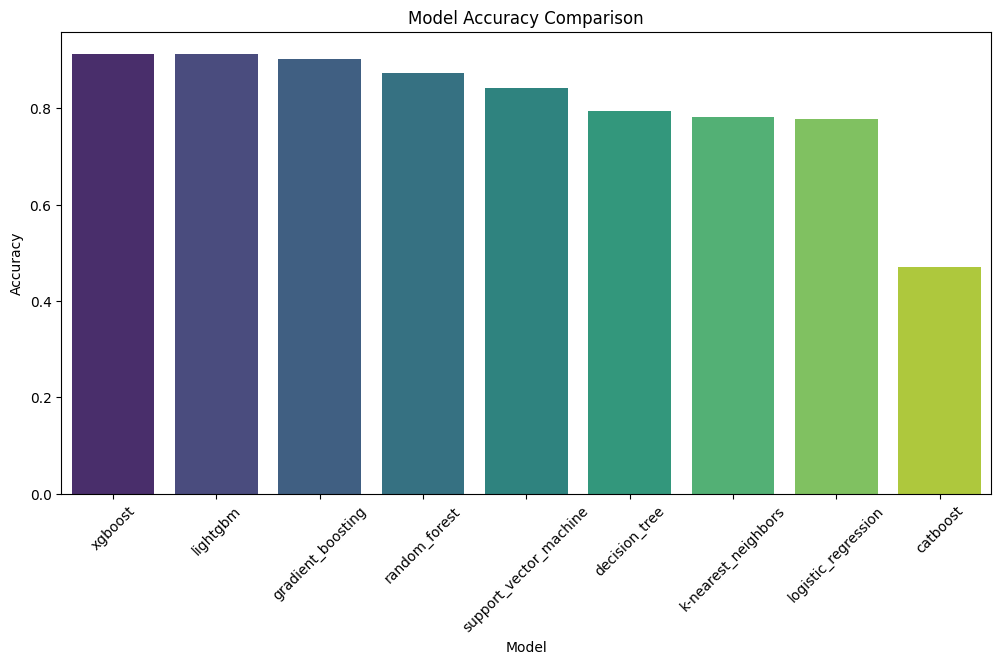

+------------------------+---------------------+---------------------+---------------------+---------------------+--------------------+
|         Model          |       Accuracy      |      Precision      |        Recall       |       F1-score      |      ROC-AUC       |
+------------------------+---------------------+---------------------+---------------------+---------------------+--------------------+
|        xgboost         |  0.913154533844189  |  0.9801136363636364 |  0.6365313653136532 |  0.7718120805369127 | 0.8435124168618554 |
|        lightgbm        |  0.9118773946360154 |  0.9970326409495549 |  0.6199261992619927 |  0.764505119453925  | 0.8276587359122068 |
|   gradient_boosting    |  0.9016602809706258 |         1.0         |  0.5738007380073801 |  0.7291910902696366 | 0.8245639650641111 |
|     random_forest      |  0.8739889314601959 |      0.98046875     | 0.46309963099630996 |  0.6290726817042607 | 0.872977065409835  |
| support_vector_machine |  0.8416347381864623 |

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
6,xgboost,0.913155,0.980114,0.636531,0.771812,0.843512
7,lightgbm,0.911877,0.997033,0.619926,0.764505,0.827659
3,gradient_boosting,0.901660,1.000000,0.573801,0.729191,0.824564
2,random_forest,0.873989,0.980469,0.463100,0.629073,0.872977
4,support_vector_machine,0.841635,0.832031,0.392989,0.533835,0.818517
1,decision_tree,0.794381,0.549249,0.607011,0.576687,0.728796
5,k-nearest_neighbors,0.782035,0.520161,0.714022,0.601866,0.829211
0,logistic_regression,0.777352,0.623377,0.088561,0.155089,0.698616
8,catboost,0.471264,0.271838,0.769373,0.401734,0.623630


In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"])

results_df.sort_values(by="Accuracy", ascending=False, inplace=True)

print("\nModel Performance Summary:\n", results_df)

results_df.to_csv("../reports/model_evaluation.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()
# %pip install tabulate
# %pip install jinja2
from tabulate import tabulate
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = results_df.columns.tolist()

for row in results_df.itertuples(index=False):
    table.add_row(row)

print(table)
print(results_df.to_markdown(index=False))
from IPython.display import display
display(results_df.style.set_caption("Model Performance Summary").set_table_styles(
    [{'selector': 'th', 'props': [('font-weight', 'bold')]}]
))


## Loading Best Model

In [5]:
best_model_name = results_df.iloc[0]["Model"]
best_model = joblib.load(f"../models/{best_model_name}.pkl")

print(f"Best Model Selected: {best_model_name.replace('_', ' ').title()}")

joblib.dump(best_model, "../models/best_model.pkl")

Best Model Selected: Xgboost


['../models/best_model.pkl']